# Day 4 — Performance Analytics
**Bluestock Mutual Fund Capstone**  
Covers: Daily Returns · CAGR · Sharpe · Sortino · Alpha/Beta · Max Drawdown · Scorecard · Benchmark Chart

## 0. Setup & Imports

In [1]:
import warnings; warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import linregress
from pathlib import Path
import os

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_rows", 50)
pd.set_option("display.float_format", "{:.4f}".format)

# ── Paths (relative to repo root) ────────────────────────────────────
PROCESSED = Path("data/processed")
REPORTS   = Path("reports")
CHARTS    = Path("reports/charts")
CHARTS.mkdir(parents=True, exist_ok=True)
(REPORTS).mkdir(parents=True, exist_ok=True)

RF_ANNUAL    = 0.065          # RBI repo rate proxy
RF_DAILY     = RF_ANNUAL / 252
TRADING_DAYS = 252

print("Libraries loaded.")
print(f"PROCESSED: {PROCESSED.resolve()}")
print(f"REPORTS:   {REPORTS.resolve()}")

Libraries loaded.
PROCESSED: /Users/prabhjotkaur/Desktop/bluestock_mf_capstone/data/processed
REPORTS:   /Users/prabhjotkaur/Desktop/bluestock_mf_capstone/reports


## Task 1 — Daily Returns
`daily_return = nav / nav.shift(1) - 1` per fund. Validate distribution.

In [2]:
# Load NAV history
nav = pd.read_csv(PROCESSED / "02_nav_history.csv", parse_dates=["date"])
nav = nav.sort_values(["amfi_code", "date"]).reset_index(drop=True)

# Load fund master for names
funds = pd.read_csv(PROCESSED / "01_fund_master.csv")
funds["amfi_code"] = pd.to_numeric(funds["amfi_code"], errors="coerce").astype("Int64").astype(str)
nav["amfi_code"]   = pd.to_numeric(nav["amfi_code"],   errors="coerce").astype("Int64").astype(str)

print(f"NAV rows: {len(nav):,}  |  Funds: {nav['amfi_code'].nunique()}")
nav.head(3)

NAV rows: 64,320  |  Funds: 40


,date,amfi_code,nav
0,2022-01-03,100016,520.4608
1,2022-01-04,100016,515.0971
2,2022-01-05,100016,521.7239


Daily Return Statistics (all funds combined):
  count   : 6428000.0000%
  mean    : 0.0451%
  std     : 0.8706%
  min     : -5.8102%
  25%     : -0.2092%
  50%     : 0.0000%
  75%     : 0.3233%
  max     : 6.4713%


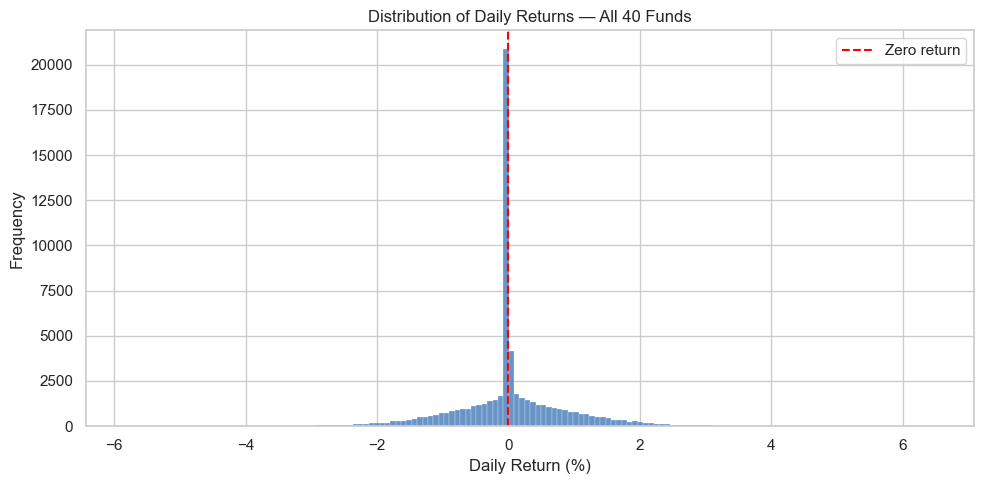

Histogram rendered.


In [3]:
# Compute daily returns per fund
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()
nav = nav.dropna(subset=["daily_return"])

print("Daily Return Statistics (all funds combined):")
stats = nav["daily_return"].describe()
for k, v in stats.items():
    print(f"  {k:8s}: {v*100:.4f}%")

# Distribution plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(nav["daily_return"] * 100, bins=150, color="#4F81BD",
        edgecolor="white", linewidth=0.2, alpha=0.85)
ax.axvline(0, color="red", linewidth=1.5, linestyle="--", label="Zero return")
ax.set_xlabel("Daily Return (%)")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Daily Returns — All 40 Funds")
ax.legend()
plt.tight_layout()
plt.show()
print("Histogram rendered.")

## Task 2 — CAGR Table (1yr / 3yr / 5yr)
`CAGR = (NAV_end / NAV_start)^(1/n) - 1`

In [4]:
def cagr(series, years):
    s = series.dropna()
    n_days = years * TRADING_DAYS
    if len(s) < n_days:
        return np.nan
    return (s.iloc[-1] / s.iloc[-int(n_days)]) ** (1 / years) - 1

cagr_rows = []
for code, grp in nav.groupby("amfi_code"):
    s = grp.set_index("date")["nav"].sort_index()
    cagr_rows.append({
        "amfi_code":  code,
        "cagr_1yr":   cagr(s, 1),
        "cagr_3yr":   cagr(s, 3),
        "cagr_5yr":   cagr(s, 5),
    })

cagr_df = (pd.DataFrame(cagr_rows)
           .merge(funds[["amfi_code","scheme_name","category","expense_ratio_pct"]],
                  on="amfi_code", how="left")
           .sort_values("cagr_3yr", ascending=False)
           .reset_index(drop=True))

print(f"CAGR computed for {len(cagr_df)} funds")
print(f"3yr NaN count: {cagr_df['cagr_3yr'].isna().sum()}")
print()
display(cagr_df[["amfi_code","scheme_name","cagr_1yr","cagr_3yr","cagr_5yr"]].round(4))

CAGR computed for 40 funds
3yr NaN count: 0



,amfi_code,scheme_name,cagr_1yr,cagr_3yr,cagr_5yr
0,119551,SBI Bluechip Fund - Regular Plan - Growth,0.3287,0.2856,0.1951
1,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.0446,0.2513,0.1832
2,149323,DSP Midcap Fund - Regular - Growth,0.1101,0.2469,0.2344
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.3572,0.2441,0.2311
4,101206,ABSL Frontline Equity Fund - Regular - Growth,0.3752,0.2240,0.1743
5,120843,Kotak Flexicap Fund - Regular - Growth,0.2506,0.2167,0.2293
6,119094,Axis Midcap Fund - Regular - Growth,0.2126,0.2129,0.2349
7,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.4029,0.2089,0.1883
8,119598,SBI Small Cap Fund - Regular Plan - Growth,0.3992,0.1893,0.1793
9,102887,UTI Flexi Cap Fund - Regular - Growth,-0.0833,0.1722,0.1636


## Task 3 — Sharpe Ratio
`Sharpe = (mean(Rp) - Rf) / std(Rp) × √252`   |   Rf = 6.5% / 252

In [5]:
sharpe_rows = []
for code, grp in nav.groupby("amfi_code"):
    r = grp["daily_return"].dropna()
    excess = r - RF_DAILY
    std    = r.std()
    sharpe_rows.append({
        "amfi_code":    code,
        "sharpe_ratio": (excess.mean() / std * np.sqrt(TRADING_DAYS)) if std > 0 else np.nan
    })

sharpe_df = (pd.DataFrame(sharpe_rows)
             .merge(funds[["amfi_code","scheme_name"]], on="amfi_code", how="left")
             .sort_values("sharpe_ratio", ascending=False)
             .reset_index(drop=True))

print("Top 15 Funds by Sharpe Ratio:")
display(sharpe_df[["amfi_code","scheme_name","sharpe_ratio"]].head(15).round(4))

Top 15 Funds by Sharpe Ratio:


,amfi_code,scheme_name,sharpe_ratio
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,1.0682
1,120843,Kotak Flexicap Fund - Regular - Growth,0.9656
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.9190
3,120505,ICICI Pru Midcap Fund - Regular - Growth,0.8833
4,119551,SBI Bluechip Fund - Regular Plan - Growth,0.8610
5,149323,DSP Midcap Fund - Regular - Growth,0.8329
6,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.8083
7,118632,Nippon India Large Cap Fund - Regular - Growth,0.7589
8,119094,Axis Midcap Fund - Regular - Growth,0.7305
9,101206,ABSL Frontline Equity Fund - Regular - Growth,0.7174


## Task 4 — Sortino Ratio
Same as Sharpe but denominator = std of **negative** return days only.

In [6]:
sortino_rows = []
for code, grp in nav.groupby("amfi_code"):
    r      = grp["daily_return"].dropna()
    excess = r - RF_DAILY
    down   = excess[excess < 0]
    dstd   = down.std()
    sortino_rows.append({
        "amfi_code":     code,
        "sortino_ratio": (excess.mean() / dstd * np.sqrt(TRADING_DAYS)) if dstd > 0 else np.nan
    })

sortino_df = pd.DataFrame(sortino_rows)

# Merge into one metrics table
metrics = (sharpe_df[["amfi_code","scheme_name","sharpe_ratio"]]
           .merge(sortino_df, on="amfi_code", how="left"))

print("Sharpe vs Sortino (top 10):")
display(metrics.head(10).round(4))

Sharpe vs Sortino (top 10):


,amfi_code,scheme_name,sharpe_ratio,sortino_ratio
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,1.0682,1.5548
1,120843,Kotak Flexicap Fund - Regular - Growth,0.9656,1.4859
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.9190,1.3870
3,120505,ICICI Pru Midcap Fund - Regular - Growth,0.8833,1.3211
4,119551,SBI Bluechip Fund - Regular Plan - Growth,0.8610,1.3025
5,149323,DSP Midcap Fund - Regular - Growth,0.8329,1.2018
6,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.8083,1.1844
7,118632,Nippon India Large Cap Fund - Regular - Growth,0.7589,1.1215
8,119094,Axis Midcap Fund - Regular - Growth,0.7305,1.0915
9,101206,ABSL Frontline Equity Fund - Regular - Growth,0.7174,1.0788


## Task 5 — Alpha & Beta (OLS vs Nifty 100)
`scipy.stats.linregress`  |  Alpha annualised = intercept × 252

In [7]:
bench = pd.read_csv(PROCESSED / "10_benchmark_indices.csv", parse_dates=["date"])
bench = bench.sort_values("date")

# Nifty 100 daily returns
nifty100 = (bench[bench["index_name"] == "NIFTY100"]
            .set_index("date")["close_value"]
            .pct_change().dropna())

print(f"Nifty100 return rows: {len(nifty100)}")
print(f"Date range: {nifty100.index.min().date()} → {nifty100.index.max().date()}")

Nifty100 return rows: 1149
Date range: 2022-01-04 → 2026-05-29


In [8]:
ab_rows = []
for code, grp in nav.groupby("amfi_code"):
    fund_ret = grp.set_index("date")["daily_return"].dropna()
    common   = fund_ret.index.intersection(nifty100.index)
    if len(common) < 60:
        ab_rows.append({"amfi_code": code, "alpha": np.nan, "beta": np.nan, "r_squared": np.nan})
        continue
    y = fund_ret.loc[common].values
    x = nifty100.loc[common].values
    slope, intercept, r, p, se = linregress(x, y)
    ab_rows.append({
        "amfi_code": code,
        "alpha":     intercept * TRADING_DAYS * 100,   # annualised %
        "beta":      round(slope, 4),
        "r_squared": round(r**2, 4),
    })

alpha_beta = (pd.DataFrame(ab_rows)
              .merge(funds[["amfi_code","scheme_name","category"]], on="amfi_code", how="left")
              .sort_values("alpha", ascending=False)
              .reset_index(drop=True))

# Save
alpha_beta[["amfi_code","scheme_name","category","alpha","beta","r_squared"]].to_csv(
    REPORTS / "alpha_beta.csv", index=False)
print(f"Saved reports/alpha_beta.csv  ({len(alpha_beta)} rows)")

print("\nTop 10 Funds by Alpha:")
display(alpha_beta[["scheme_name","alpha","beta","r_squared"]].head(10).round(4))

Saved reports/alpha_beta.csv  (40 rows)

Top 10 Funds by Alpha:


,scheme_name,alpha,beta,r_squared
0,SBI Small Cap Fund - Regular Plan - Growth,30.3370,-0.0232,0.0001
1,DSP Small Cap Fund - Regular - Growth,30.0579,0.0115,0.0000
2,ICICI Pru Midcap Fund - Regular - Growth,29.2636,0.0005,0.0000
3,Mirae Asset Tax Saver Fund - Regular - Growth,28.2704,0.0181,0.0002
4,Kotak Flexicap Fund - Regular - Growth,27.3305,-0.0228,0.0003
5,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,27.1954,0.0051,0.0000
6,Mirae Asset Large Cap Fund - Regular - Growth,26.9838,0.0237,0.0005
7,DSP Midcap Fund - Regular - Growth,26.5986,-0.0025,0.0000
8,Axis Midcap Fund - Regular - Growth,26.0767,-0.0663,0.0019
9,SBI Bluechip Fund - Regular Plan - Growth,23.2010,-0.0318,0.0009


## Task 6 — Maximum Drawdown
`drawdown = nav / running_max - 1`  |  Find worst trough and its peak.

In [9]:
dd_rows = []
for code, grp in nav.groupby("amfi_code"):
    g = grp.set_index("date")["nav"].sort_index()
    running_max  = g.cummax()
    drawdown     = g / running_max - 1
    max_dd       = drawdown.min()
    trough_date  = drawdown.idxmin()
    # peak = last time running_max was updated before trough
    peak_date    = running_max.loc[:trough_date].idxmax()
    dd_rows.append({
        "amfi_code":    code,
        "max_drawdown": max_dd,
        "peak_date":    str(peak_date)[:10],
        "trough_date":  str(trough_date)[:10],
    })

dd_df = pd.DataFrame(dd_rows)

print("5 Worst Drawdowns:")
worst = (dd_df.merge(funds[["amfi_code","scheme_name"]], on="amfi_code", how="left")
             .sort_values("max_drawdown")
             .head(5))
display(worst[["scheme_name","max_drawdown","peak_date","trough_date"]].round(4))

5 Worst Drawdowns:


,scheme_name,max_drawdown,peak_date,trough_date
22,SBI Small Cap Fund - Direct Plan - Growth,-0.5257,2023-01-17,2025-10-28
17,Axis Small Cap Fund - Regular - Growth,-0.5168,2025-05-22,2026-05-11
4,ABSL Small Cap Fund - Regular - Growth,-0.3545,2024-11-21,2026-05-11
39,DSP Small Cap Fund - Regular - Growth,-0.3117,2024-05-03,2025-01-03
21,SBI Small Cap Fund - Regular Plan - Growth,-0.2871,2024-08-28,2025-05-14


## Task 7 — Fund Scorecard (0–100 Composite)
`30% CAGR3yr + 25% Sharpe + 20% Alpha + 15% Expense(inv) + 10% MaxDD(inv)`

In [10]:
# Build master metrics table
sc = (cagr_df[["amfi_code","scheme_name","category","expense_ratio_pct","cagr_3yr"]]
      .merge(sharpe_df[["amfi_code","sharpe_ratio"]], on="amfi_code", how="left")
      .merge(sortino_df, on="amfi_code", how="left")
      .merge(alpha_beta[["amfi_code","alpha","beta","r_squared"]], on="amfi_code", how="left")
      .merge(dd_df[["amfi_code","max_drawdown","peak_date","trough_date"]], on="amfi_code", how="left"))

n = len(sc)

def pct_rank(col, ascending=False):
    """Percentile rank 0-100; ascending=False means higher value → higher score."""
    r = sc[col].rank(ascending=ascending, na_option="bottom")
    return (r - 1) / (n - 1) * 100

sc["score_cagr3"]  = pct_rank("cagr_3yr",         ascending=False)
sc["score_sharpe"] = pct_rank("sharpe_ratio",      ascending=False)
sc["score_alpha"]  = pct_rank("alpha",             ascending=False)
sc["score_exp"]    = pct_rank("expense_ratio_pct", ascending=True)   # lower = better
sc["score_dd"]     = pct_rank("max_drawdown",      ascending=False)  # less negative = better

sc["composite_score"] = (
    0.30 * sc["score_cagr3"]  +
    0.25 * sc["score_sharpe"] +
    0.20 * sc["score_alpha"]  +
    0.15 * sc["score_exp"]    +
    0.10 * sc["score_dd"]
)

sc = sc.sort_values("composite_score", ascending=False).reset_index(drop=True)
sc["rank"] = sc.index + 1

# Save
out_cols = ["rank","amfi_code","scheme_name","category","cagr_3yr","sharpe_ratio",
            "sortino_ratio","alpha","beta","expense_ratio_pct","max_drawdown",
            "peak_date","trough_date","composite_score"]
sc[out_cols].to_csv(REPORTS / "fund_scorecard.csv", index=False)
print(f"Saved reports/fund_scorecard.csv  ({len(sc)} rows)")
print()
print("Full Scorecard (all 40 funds):")
display(sc[["rank","scheme_name","category","cagr_3yr","sharpe_ratio",
            "alpha","expense_ratio_pct","max_drawdown","composite_score"]].round(3))

Saved reports/fund_scorecard.csv  (40 rows)

Full Scorecard (all 40 funds):


,rank,scheme_name,category,cagr_3yr,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown,composite_score
0,1,HDFC Top 100 Fund - Regular Plan - Growth,Equity,-0.0180,-0.3210,3.7480,1.5500,-0.2470,87.9490
1,2,UTI Mid Cap Fund - Regular - Growth,Equity,-0.0370,-0.2950,2.8970,1.5100,-0.2800,86.7310
2,3,Axis Small Cap Fund - Regular - Growth,Equity,-0.0970,-0.1520,4.8020,1.3800,-0.5170,84.2310
3,4,ABSL Small Cap Fund - Regular - Growth,Equity,-0.0560,0.0530,10.8970,1.5300,-0.3540,79.2950
4,5,Axis Bluechip Fund - Regular - Growth,Equity,0.0010,-0.1310,6.9000,1.6400,-0.1440,78.2690
5,6,SBI Small Cap Fund - Direct Plan - Growth,Equity,-0.0350,-0.1360,4.8820,0.7200,-0.5260,76.6030
6,7,Kotak Emerging Equity Fund - Regular - Growth,Equity,0.0980,-0.0580,7.8040,1.5600,-0.2400,70.5130
7,8,ABSL Liquid Fund - Regular - Growth,Debt,0.0430,-4.6500,6.0860,0.7900,-0.0020,69.6150
8,9,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,0.0290,-0.7430,5.6210,0.7700,-0.0430,68.2050
9,10,HDFC Short Term Debt Fund - Regular - Growth,Debt,0.0410,-1.0400,4.2820,0.5600,-0.0430,67.8210


## Task 8 — Benchmark Comparison Chart
Top 5 funds vs Nifty 50 & Nifty 100, last 3 years, normalised to 100.

In [11]:
# Top 5 funds by composite score
top5 = sc.head(5)
top5_codes = [str(c) for c in top5["amfi_code"].tolist()]
top5_names = {
    str(r["amfi_code"]): str(r["scheme_name"]) if pd.notna(r["scheme_name"]) else str(r["amfi_code"])
    for _, r in top5.iterrows()
}

# Ensure date is datetime in nav
nav["date"] = pd.to_datetime(nav["date"])
bench["date"] = pd.to_datetime(bench["date"])

# 3-year cutoff
latest = nav["date"].max()
cutoff = latest - pd.DateOffset(years=3)

# Wide NAV matrix for top 5
nav_top5 = (nav.assign(amfi_code=nav["amfi_code"].astype(str))
            [lambda d: d["amfi_code"].isin(top5_codes)]
            .query("date >= @cutoff")
            .pivot(index="date", columns="amfi_code", values="nav"))

# Benchmark series
bench_pivot = (bench.query("date >= @cutoff")
               .pivot(index="date", columns="index_name", values="close_value"))

print(f"NAV top5 shape: {nav_top5.shape}")
print(f"Bench pivot shape: {bench_pivot.shape}")

# Normalise to 100 at first valid row
def normalise(df):
    first_valid = df.apply(lambda c: c.first_valid_index())
    result = df.copy()
    for col in df.columns:
        fv = first_valid[col]
        if fv is not None and df.loc[fv, col] != 0:
            result[col] = df[col] / df.loc[fv, col] * 100
    return result

nav_norm   = normalise(nav_top5)
bench_norm = normalise(bench_pivot[["NIFTY50","NIFTY100"]])

# Tracking error per fund vs Nifty 100
nifty100_ret = bench_pivot["NIFTY100"].pct_change().dropna()
te_info = {}
for code in top5_codes:
    if code not in nav_top5.columns:
        continue
    f_ret  = nav_top5[code].pct_change().dropna()
    common = f_ret.index.intersection(nifty100_ret.index)
    if len(common) > 30:
        diff = f_ret.loc[common] - nifty100_ret.loc[common]
        te   = diff.std() * np.sqrt(TRADING_DAYS) * 100
        te_info[code] = te

print(f"Tracking errors computed: {len(te_info)}")
for code, te in te_info.items():
    name = top5_names.get(str(code), str(code))
    print(f"  {name[:40]}: {float(te):.2f}%")

NAV top5 shape: (1097, 5)
Bench pivot shape: (785, 7)
Tracking errors computed: 5
  HDFC Top 100 Fund - Regular Plan - Growt: 19.54%
  UTI Mid Cap Fund - Regular - Growth: 22.34%
  Axis Small Cap Fund - Regular - Growth: 28.35%
  ABSL Small Cap Fund - Regular - Growth: 29.31%
  Axis Bluechip Fund - Regular - Growth: 18.59%


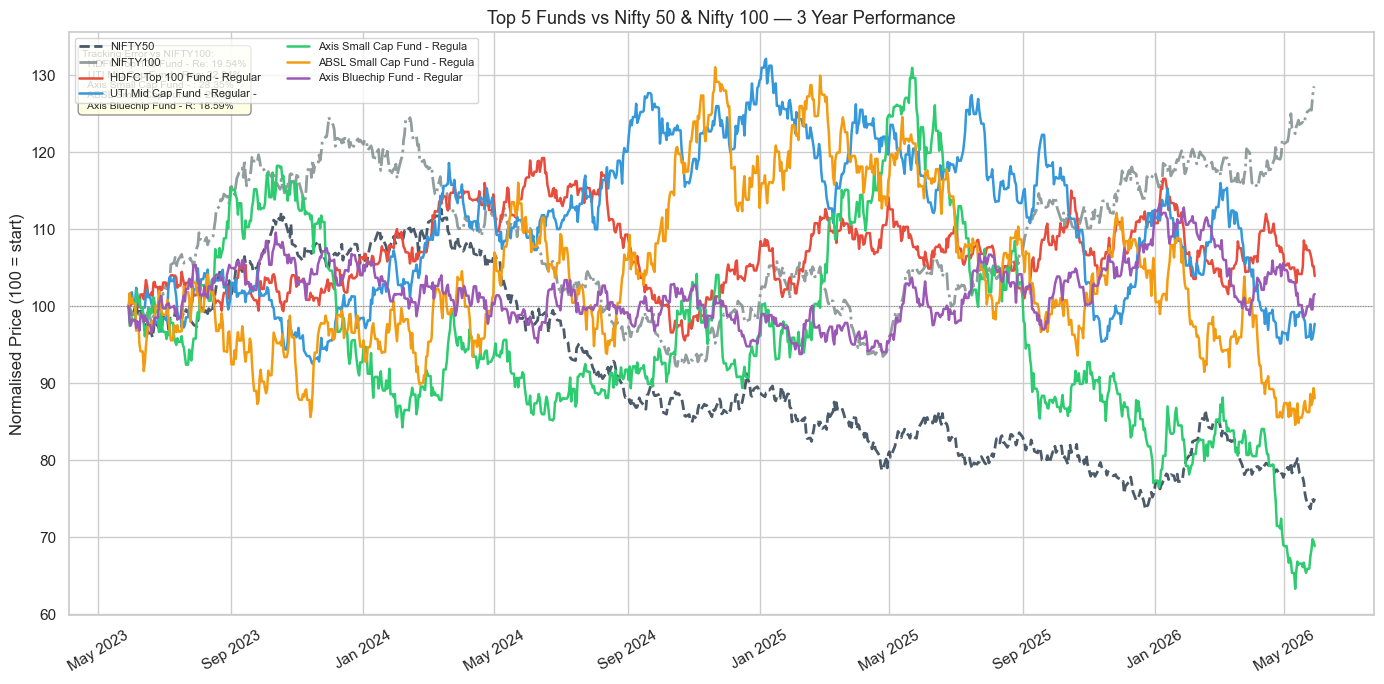

Saved reports/charts/benchmark_comparison.png  (494.1 KB)


In [12]:
COLORS_FUND  = ["#E74C3C","#3498DB","#2ECC71","#F39C12","#9B59B6"]
COLORS_BENCH = {"NIFTY50":"#2C3E50","NIFTY100":"#7F8C8D"}

fig, ax = plt.subplots(figsize=(14, 7))

# Benchmark lines
for idx in ["NIFTY50","NIFTY100"]:
    if idx in bench_norm.columns:
        ax.plot(bench_norm.index, bench_norm[idx],
                color=COLORS_BENCH[idx], linewidth=2,
                linestyle="--" if idx=="NIFTY50" else "-.",
                label=idx, alpha=0.85)

# Fund lines
for i, code in enumerate(top5_codes):
    if code not in nav_norm.columns:
        continue
    name = top5_names.get(str(code), str(code))[:28]
    ax.plot(nav_norm.index, nav_norm[code],
            color=COLORS_FUND[i], linewidth=1.8, label=name)

# Tracking error annotation box
te_text = "Tracking Error vs NIFTY100:\n"
for i, code in enumerate(top5_codes):
    if code in te_info:
        nm = top5_names.get(str(code), str(code))[:22]
        te_text += f"  {nm}: {float(te_info[code]):.2f}%\n"
ax.text(0.01, 0.97, te_text.strip(),
        transform=ax.transAxes, fontsize=7.5,
        verticalalignment="top",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="lightyellow",
                  edgecolor="grey", alpha=0.85))

ax.axhline(100, color="grey", linewidth=0.7, linestyle=":")
ax.set_ylabel("Normalised Price (100 = start)")
ax.set_title("Top 5 Funds vs Nifty 50 & Nifty 100 — 3 Year Performance", fontsize=13)
ax.legend(loc="upper left", fontsize=8, ncol=2)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b %Y"))
plt.xticks(rotation=30)
plt.tight_layout()

out_path = CHARTS / "benchmark_comparison.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {out_path}  ({os.path.getsize(out_path)/1024:.1f} KB)")

## Final Summary — Top 10 Funds

In [13]:
# Tracking error for all funds (top 5 computed above)
te_series = pd.Series(te_info, name="tracking_error_pct").rename_axis("amfi_code").reset_index()

summary = (sc[["rank","amfi_code","scheme_name","composite_score","sharpe_ratio",
               "alpha","cagr_3yr","max_drawdown"]]
           .head(10)
           .merge(te_series, on="amfi_code", how="left"))

print("="*80)
print("TOP 10 FUNDS — BLUESTOCK PERFORMANCE SCORECARD")
print("="*80)
display(summary.set_index("rank").round(3))

print()
print("Output files:")
for f in [REPORTS/"fund_scorecard.csv", REPORTS/"alpha_beta.csv",
          CHARTS/"benchmark_comparison.png"]:
    size = os.path.getsize(f)/1024 if f.exists() else 0
    status = "OK" if f.exists() else "MISSING"
    print(f"  [{status}] {str(f):<50} {size:.1f} KB")

TOP 10 FUNDS — BLUESTOCK PERFORMANCE SCORECARD


,amfi_code,scheme_name,composite_score,sharpe_ratio,alpha,cagr_3yr,max_drawdown,tracking_error_pct
rank,,,,,,,,
1,100016,HDFC Top 100 Fund - Regular Plan - Growth,87.9490,-0.3210,3.7480,-0.0180,-0.2470,19.5400
2,102886,UTI Mid Cap Fund - Regular - Growth,86.7310,-0.2950,2.8970,-0.0370,-0.2800,22.3430
3,119095,Axis Small Cap Fund - Regular - Growth,84.2310,-0.1520,4.8020,-0.0970,-0.5170,28.3520
4,101207,ABSL Small Cap Fund - Regular - Growth,79.2950,0.0530,10.8970,-0.0560,-0.3540,29.3100
5,119092,Axis Bluechip Fund - Regular - Growth,78.2690,-0.1310,6.9000,0.0010,-0.1440,18.5940
6,119599,SBI Small Cap Fund - Direct Plan - Growth,76.6030,-0.1360,4.8820,-0.0350,-0.5260,NaN
7,120842,Kotak Emerging Equity Fund - Regular - Growth,70.5130,-0.0580,7.8040,0.0980,-0.2400,NaN
8,101208,ABSL Liquid Fund - Regular - Growth,69.6150,-4.6500,6.0860,0.0430,-0.0020,NaN
9,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,68.2050,-0.7430,5.6210,0.0290,-0.0430,NaN



Output files:
  [OK] reports/fund_scorecard.csv                         8.3 KB
  [OK] reports/alpha_beta.csv                             3.5 KB
  [OK] reports/charts/benchmark_comparison.png            494.1 KB
